<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/HF_vs_NF_GE_plot_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HF vs NF Combined GE Heatmap

## Block 1: Environment Setup & Scientific Styling
Create a new cell in Colab, paste this code, and run it to set up publication-ready

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set scientific publication styling
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# Define morph palette
MORPH_COLORS = {
    'Fluorescent': '#2ca02c',       # HF - Green
    'HF': '#2ca02c',
    'Non-fluorescent': '#d62728',   # NF - Red
    'NF': '#d62728'
}

print("✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).")

✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).


## Block 2: Data Loading & Directional Normalization
This block loads HF_NF_57_each_plot_ready.csv, cleans character strings, ensures that NF fold-changes diverge to the left (negative values) around the $0$ baseline, and orders the biological categories logically.

In [12]:
# 1. Load CSV dataset
file_path = 'HF_NF_57_each_plot_ready.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded {file_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Please upload it to your Colab session.")
    raise

# 2. Clean column headers and text fields
df.columns = df.columns.str.strip()
df['Condition'] = df['Condition'].str.strip()
df['Primary_category'] = df['Primary_category'].str.strip()
df['Description'] = df['Description'].str.strip()

# 3. Standardize log2FoldChange direction (HF positive -> right, NF negative -> left)
# If NF values are positive in raw CSV, negate them for the diverging plot
df['plot_lfc'] = df.apply(
    lambda row: -abs(row['log2FoldChange']) if 'Non' in row['Condition'] or 'NF' in row['Condition']
    else abs(row['log2FoldChange']),
    axis=1
)

# 4. Clean description text for plot labels (strip redundant 'like' or 'LOC' prefixes)
df['Clean_Label'] = df['Description'].str.replace('-like', '', case=False)
df['Clean_Label'] = df['Clean_Label'].str.replace('uncharacterized ', '', case=False)

# 5. Define preferred order for Biological Categories
category_order = [
    'ECM/adhesion',
    'Biomineralization',
    'Cytoskeleton',
    'Metabolism',
    'Morphogenesis',
    'Redox regulation',
    'Immunity',
    'Nuclear/cell cycle',
    'GFP',
    'Neuro-sensing',
    'Other'
]

# Keep categories present in data while preserving order
present_categories = [cat for cat in category_order if cat in df['Primary_category'].unique()]
remaining = [cat for cat in df['Primary_category'].unique() if cat not in present_categories]
final_category_order = present_categories + remaining

print(f"✅ Preprocessed {len(df)} DEGs across {len(final_category_order)} biological categories.")

✅ Successfully loaded HF_NF_57_each_plot_ready.csv
✅ Preprocessed 114 DEGs across 11 biological categories.


## Block 3: Recreating the Grouped DEG Diverging Plot
This block generates the multi-panel layout matching the PDF. Each biological category gets its own dedicated panel block sharing a single $\log_2\text{FC}$ baseline X-axis.

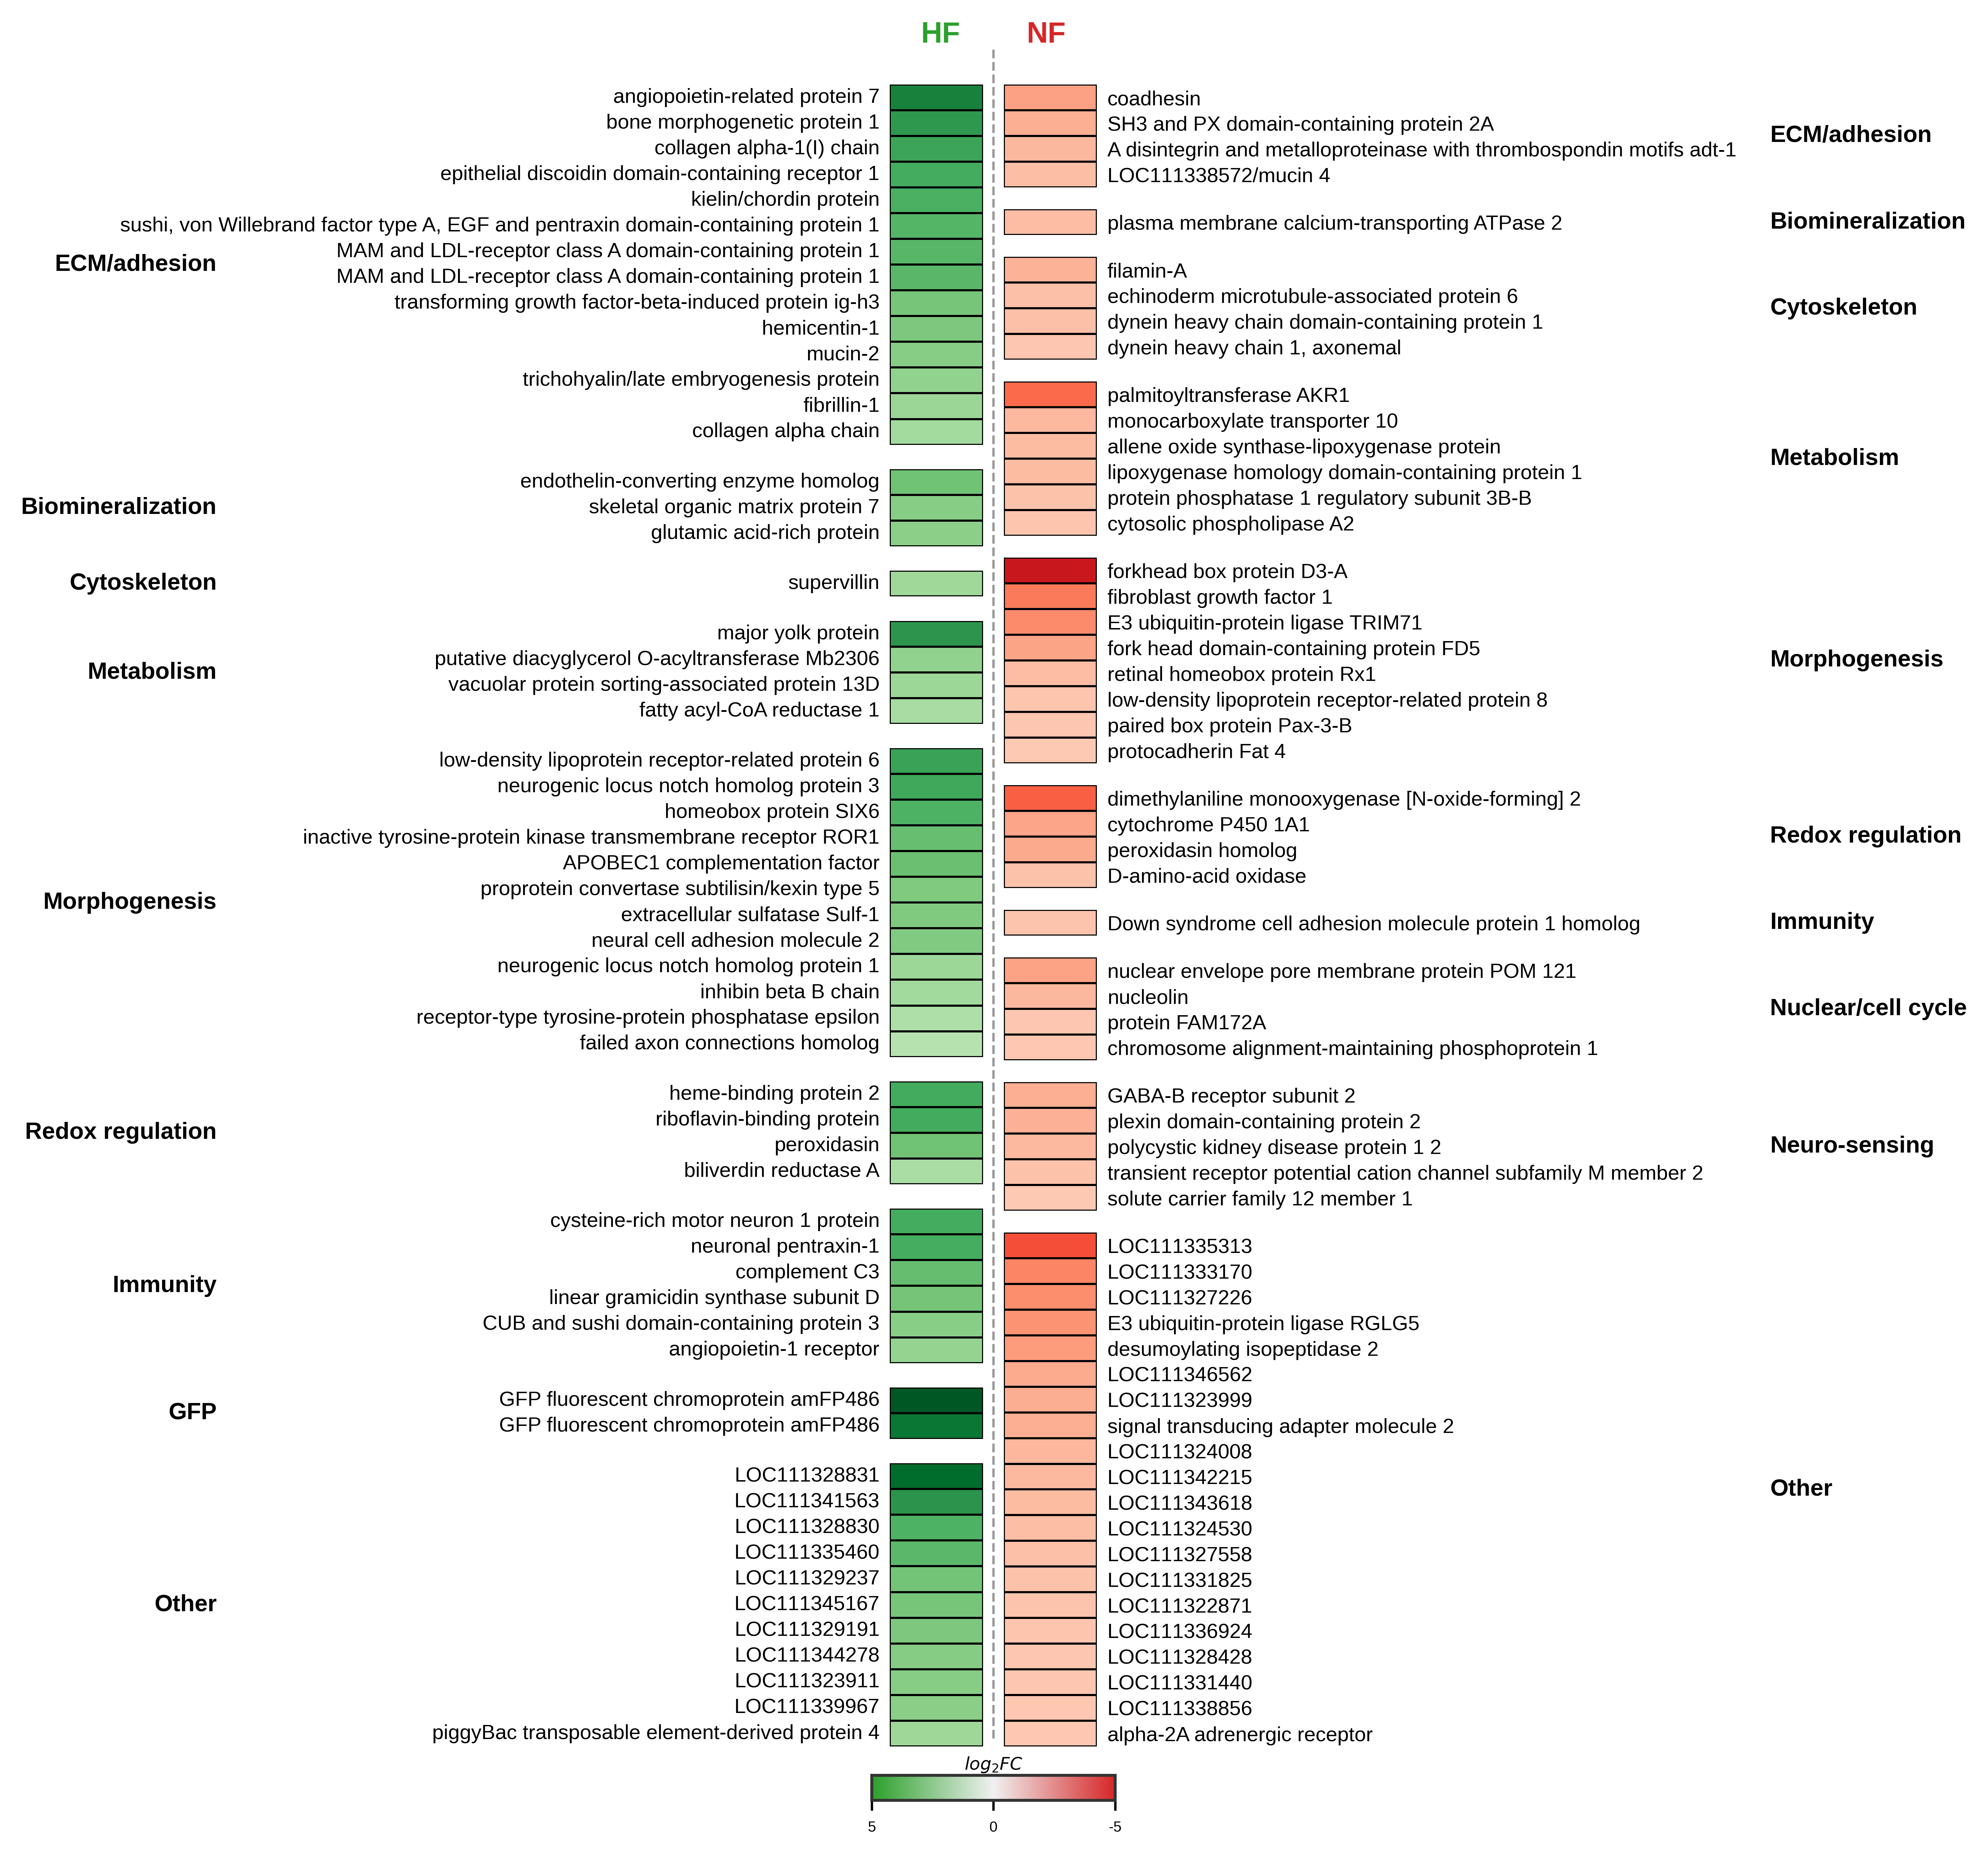

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- MANUAL ADJUSTMENTS ---
cat_label_offset_hf = 1.3
cat_label_offset_nf = 1.3
center_gap_inch = 0.1      # Horizontal distance between HF/NF heatmap columns and the dashed line
title_y_offset = 0.0001    # Vertical adjustment for HF/NF titles (increase to move up)
title_x_offset = 0.25      # Horizontal distance of titles from center (increase to move to edges)
colorbar_y_offset = 0.1    # Vertical position of colorbar (default 0.04; decrease to move down, increase to move up)
# --------------------------

# 1. Filter genes: HF positive, NF negative
df_hf = df[df['plot_lfc'] > 0].copy()
df_nf = df[df['plot_lfc'] < 0].copy()

# 2. Gene lists per category
hf_plot_cats = [(cat, len(df_hf[df_hf['Primary_category'] == cat])) for cat in final_category_order if len(df_hf[df_hf['Primary_category'] == cat]) > 0]
nf_plot_cats = [(cat, len(df_nf[df_nf['Primary_category'] == cat])) for cat in final_category_order if len(df_nf[df_nf['Primary_category'] == cat]) > 0]

# 3. Geometry
gene_height_inch = 0.15
hm_col_width_inch = gene_height_inch * 3.0
max_total_genes = max(sum(c[1] for c in hf_plot_cats), sum(c[1] for c in nf_plot_cats))

# Height allocations
header_section_height = 0.2
footer_section_height = 0.3
fig_height = (max_total_genes * gene_height_inch) + 1.2

label_width = 2.5
total_fig_width = (label_width * 2) + (hm_col_width_inch * 2) + center_gap_inch

fig = plt.figure(figsize=(total_fig_width, fig_height))

# Main layout grid
main_gs = gridspec.GridSpec(3, 5, figure=fig,
                           height_ratios=[header_section_height, fig_height - header_section_height - footer_section_height, footer_section_height],
                           width_ratios=[label_width, hm_col_width_inch, center_gap_inch, hm_col_width_inch, label_width],
                           wspace=0.0, hspace=0.0)

category_hspace = 0.15

# Subgrids
gs_cat_l = gridspec.GridSpecFromSubplotSpec(len(hf_plot_cats), 1, subplot_spec=main_gs[1, 0], height_ratios=[c[1] for c in hf_plot_cats], hspace=category_hspace)
gs_hf = gridspec.GridSpecFromSubplotSpec(len(hf_plot_cats), 1, subplot_spec=main_gs[1, 1], height_ratios=[c[1] for c in hf_plot_cats], hspace=category_hspace)
gs_nf = gridspec.GridSpecFromSubplotSpec(len(nf_plot_cats), 1, subplot_spec=main_gs[1, 3], height_ratios=[c[1] for c in nf_plot_cats], hspace=category_hspace)
gs_cat_r = gridspec.GridSpecFromSubplotSpec(len(nf_plot_cats), 1, subplot_spec=main_gs[1, 4], height_ratios=[c[1] for c in nf_plot_cats], hspace=category_hspace)

cbar_min, cbar_max = -5, 5
cmap_div_rev = LinearSegmentedColormap.from_list('rev_green_red', ['#2ca02c', '#f0f0f0', '#d62728'])

# --- HF/NF Titles (TOP) ---
mid_x_fig = (label_width + hm_col_width_inch + (center_gap_inch / 2)) / total_fig_width
title_x_hf = mid_x_fig - (title_x_offset / total_fig_width)
title_x_nf = mid_x_fig + (title_x_offset / total_fig_width)
title_y_base = 0.95 + title_y_offset

fig.text(title_x_hf, title_y_base, 'HF', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ca02c')
fig.text(title_x_nf, title_y_base, 'NF', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d62728')

# --- Colorbar (BOTTOM) ---
cbar_ax = fig.add_axes([0.404, colorbar_y_offset, 0.192, 0.012])
smb = plt.cm.ScalarMappable(cmap=cmap_div_rev, norm=plt.Normalize(vmin=cbar_min, vmax=cbar_max))
cbar = fig.colorbar(smb, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([cbar_min, 0, cbar_max])
cbar.set_ticklabels([5, 0, -5])
cbar_ax.set_title('$log_2{FC}$', fontsize=6, pad=2)
cbar.ax.tick_params(labelsize=5)

# --- Central Divider ---
mid_x = (label_width + hm_col_width_inch + (center_gap_inch / 2)) / total_fig_width
# Further adjusted ymin from 0.15 to 0.2 to ensure no overlap with color bar area
fig.add_artist(plt.Line2D((mid_x, mid_x), (0.13, 0.95), color='black', alpha=0.4, lw=0.8, linestyle='--', transform=fig.transFigure, zorder=0))

# --- Plots ---
for i, (cat, count) in enumerate(hf_plot_cats):
    ax_cat = fig.add_subplot(gs_cat_l[i])
    ax_cat.axis('off')
    ax_cat.text(1.0 - cat_label_offset_hf, 0.5, cat, transform=ax_cat.transAxes, fontsize=8, fontweight='bold', ha='right', va='center')
    cat_data = df_hf[df_hf['Primary_category'] == cat].sort_values(by='plot_lfc', ascending=False)
    ax_hm = fig.add_subplot(gs_hf[i])
    sns.heatmap(cat_data['plot_lfc'].values.reshape(-1, 1), cmap='Greens', vmin=0, vmax=cbar_max, cbar=False, ax=ax_hm, xticklabels=False, yticklabels=cat_data['Clean_Label'].values, linewidths=0.5, linecolor='black')
    ax_hm.tick_params(axis='y', labelsize=7, rotation=0, length=0)

for i, (cat, count) in enumerate(nf_plot_cats):
    cat_data = df_nf[df_nf['Primary_category'] == cat].sort_values(by='plot_lfc', ascending=True)
    ax_hm = fig.add_subplot(gs_nf[i])
    sns.heatmap(cat_data['plot_lfc'].abs().values.reshape(-1, 1), cmap='Reds', vmin=0, vmax=cbar_max, cbar=False, ax=ax_hm, xticklabels=False, yticklabels=cat_data['Clean_Label'].values, linewidths=0.5, linecolor='black')
    ax_hm.yaxis.tick_right()
    ax_hm.tick_params(axis='y', labelsize=7, rotation=0, length=0)
    ax_cat = fig.add_subplot(gs_cat_r[i])
    ax_cat.axis('off')
    ax_cat.text(cat_label_offset_nf, 0.5, cat, transform=ax_cat.transAxes, fontsize=8, fontweight='bold', ha='left', va='center')

plt.subplots_adjust(top=0.95, bottom=0.1, left=0.01, right=0.99)
plt.show()

## Exporting Final Visualization
Saving the figure in high-resolution (600 DPI) for publication.

In [14]:
# Define filename base
output_filename = 'Gene_Expression_Split_Heatmap'

# Save in multiple formats at 600 DPI
fig.savefig(f'{output_filename}.png', dpi=600, bbox_inches='tight', format='png')
fig.savefig(f'{output_filename}.svg', dpi=600, bbox_inches='tight', format='svg')
fig.savefig(f'{output_filename}.tiff', dpi=600, bbox_inches='tight', format='tiff')

print(f"✅ Successfully saved plot as:")
print(f" - {output_filename}.png")
print(f" - {output_filename}.svg")
print(f" - {output_filename}.tiff")

✅ Successfully saved plot as:
 - Gene_Expression_Split_Heatmap.png
 - Gene_Expression_Split_Heatmap.svg
 - Gene_Expression_Split_Heatmap.tiff


# Biomineralization & GFP Target Expression Plot

## Block 1: Environment Setup & Scientific Styling

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set scientific publication styling
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# Define morph palette
MORPH_COLORS = {
    'Fluorescent': '#2ca02c',       # HF - Green
    'HF': '#2ca02c',
    'Non-fluorescent': '#d62728',   # NF - Red
    'NF': '#d62728'
}

print("✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).")

✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).


## Block 2: Data Loading & Preprocessing
It cleans the gene descriptions from your biomineralization_gfp_presence.csv file, formats gene symbol labels, and sorts the data by Log$_2$ Fold Change:

In [6]:
# 1. Load CSV dataset
file_path = 'biomineralization_gfp_presence.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded {file_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Please upload it to your Colab workspace.")
    raise

# 2. Clean text fields
df.columns = df.columns.str.strip()
df['Expression'] = df['Expression'].str.strip()
df['Description'] = df['Description'].str.strip()
df['Symbol'] = df['Symbol'].str.strip()

# 3. Simplify gene descriptions for publication labels
df['Clean_Label'] = df['Description'].str.replace('-like', '', case=False)
df['Clean_Label'] = df['Clean_Label'].str.replace('uncharacterized ', '', case=False)

# Combine gene label with Symbol for full annotation (wrapped to new line for plot width)
df['Full_Label'] = df['Clean_Label'] + '\n(' + df['Symbol'] + ')'

# 4. Standardize directionality (Positive = Upregulated in HF, Negative = Upregulated in NF)
df['plot_lfc'] = df.apply(
    lambda row: -abs(row['log2FoldChange']) if 'Non' in str(row['Expression'])
    else abs(row['log2FoldChange']),
    axis=1
)

# 5. Sort by fold change magnitude
df_sorted = df.sort_values(by='plot_lfc', ascending=True).reset_index(drop=True)

print(f"✅ Processed {len(df_sorted)} biomineralization and GFP target genes with multi-line labels.")

✅ Successfully loaded biomineralization_gfp_presence.csv
✅ Processed 12 biomineralization and GFP target genes with multi-line labels.


## Block 3: Generating the Biomineralization & GFP Plot
render the horizontal diverging bar plot and export high-resolution figure files

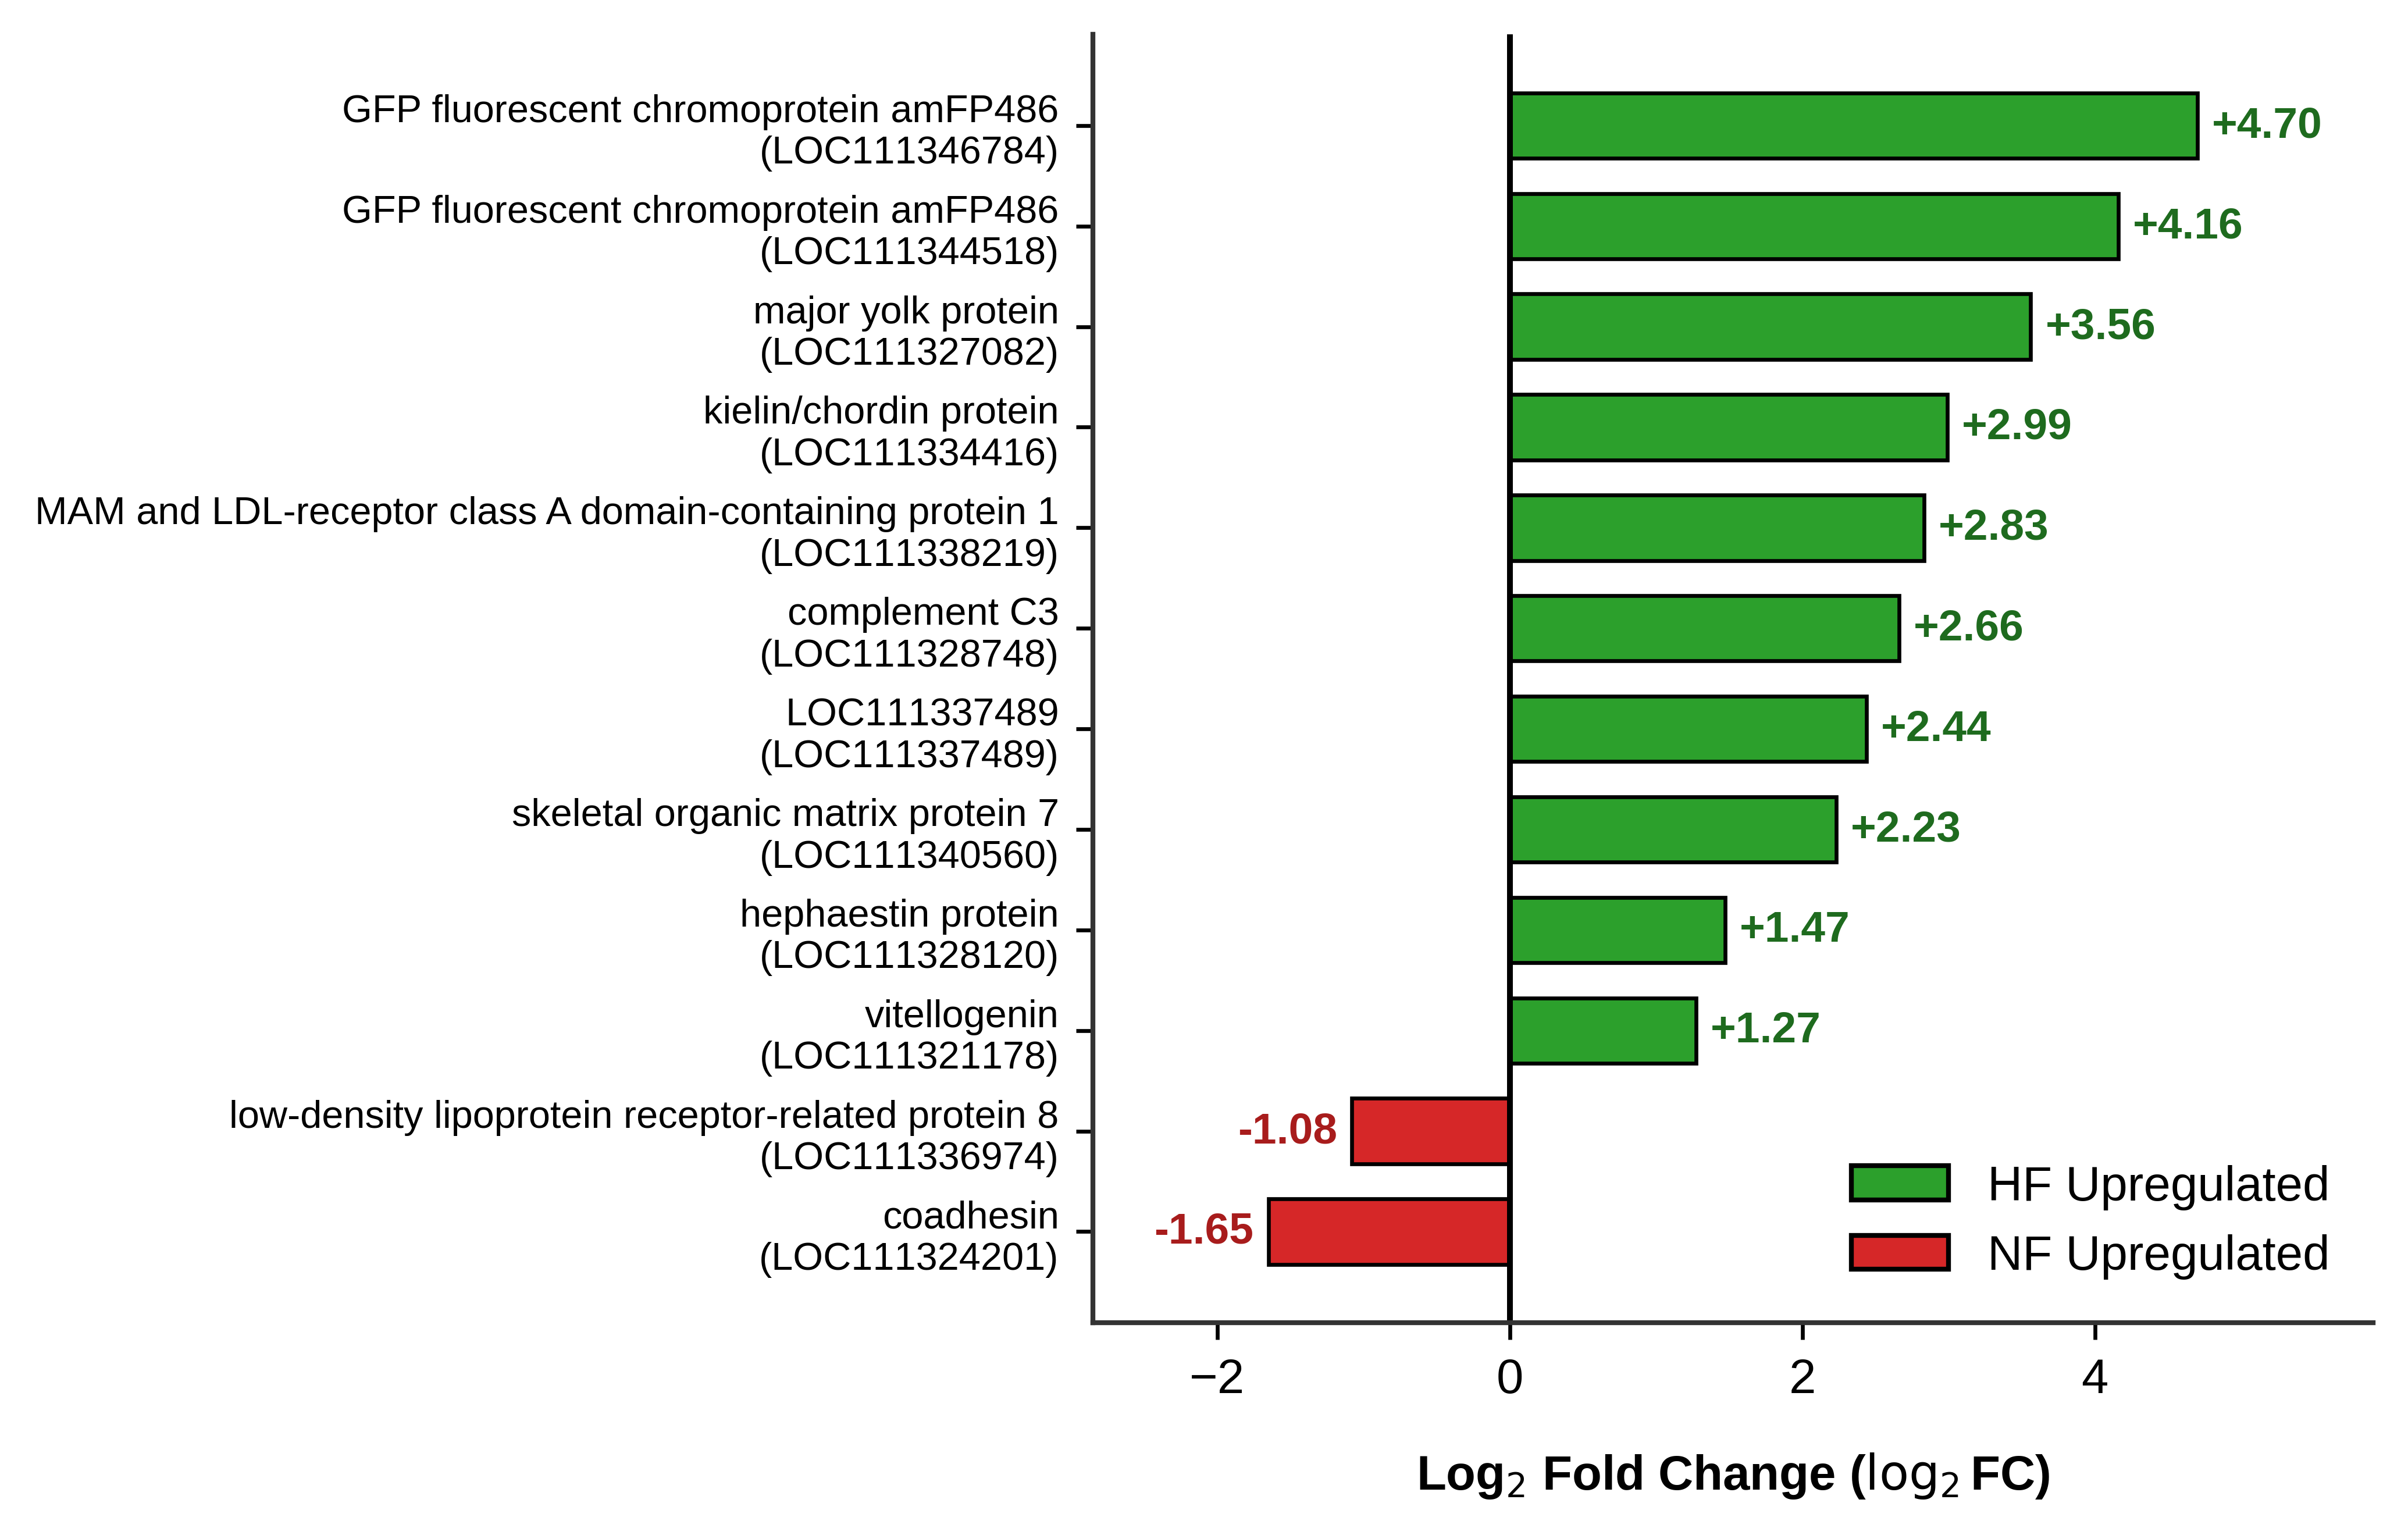

In [18]:
# Initialize figure
fig, ax = plt.subplots(figsize=(7, 4.5))

# Define bar colors based on morph upregulation using the original palette
bar_colors = [
    MORPH_COLORS['Fluorescent'] if val > 0 else MORPH_COLORS['Non-fluorescent']
    for val in df_sorted['plot_lfc']
]

# Draw horizontal bar chart
bars = ax.barh(
    y=df_sorted['Full_Label'],
    width=df_sorted['plot_lfc'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.65
)

# Add central zero line
ax.axvline(0, color='black', linewidth=1.2, linestyle='-')

# Add explicit log2FC numeric labels on each bar
for bar in bars:
    val = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2.0
    if val > 0:
        ax.text(val + 0.1, y_pos, f'+{val:.2f}', va='center', ha='left', fontsize=9, fontweight='bold', color='#1e6b1e')
    else:
        ax.text(val - 0.1, y_pos, f'{val:.2f}', va='center', ha='right', fontsize=9, fontweight='bold', color='#a81c1c')

# Formatting axes & y-tick font size
ax.set_xlabel(r'Log$_{2}$ Fold Change ($\log_{2}$FC)', fontsize=10, fontweight='bold', labelpad=10)
ax.tick_params(axis='y', labelsize=8)

# Remove grid lines
ax.grid(False)

# Adjust x-axis limits for label clearance
min_val, max_val = df_sorted['plot_lfc'].min(), df_sorted['plot_lfc'].max()
ax.set_xlim(min_val - 1.2, max_val + 1.2)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend setup
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=MORPH_COLORS['Fluorescent'], edgecolor='black', label='HF Upregulated'),
    Patch(facecolor=MORPH_COLORS['Non-fluorescent'], edgecolor='black', label='NF Upregulated')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=10)

plt.tight_layout()

# Exporting the figure
output_base = 'Biomineralization_GFP_Expression_Plot'
fig.savefig(f'{output_base}.png', dpi=600, bbox_inches='tight', format='png')
fig.savefig(f'{output_base}.svg', dpi=600, bbox_inches='tight', format='svg')
fig.savefig(f'{output_base}.tiff', dpi=600, bbox_inches='tight', format='tiff')

plt.show()

# GSEA

## Block 1: Load and Process GSEA Data

In [8]:
import pandas as pd
import numpy as np

# 1. Load the GSEA CSV file
gsea_file = 'GSEA_cell.atlas_HF_vs_NF.csv'
df_gsea = pd.read_csv(gsea_file)

# 2. Clean pathway labels for publication
pathway_map = {
    'cnidocyte': 'Cnidocyte',
    'immune_1_adult': 'Immunity 1 (Adult)',
    'immune_2_adult': 'Immunity 2 (Adult)',
    'neuron_1': 'Neuron 1',
    'neuron_2': 'Neuron 2',
    'gland_1': 'Gland 1',
    'gland_2': 'Gland 2',
    'gland_3': 'Gland 3'
}

df_gsea['Clean_Pathway'] = df_gsea['pathway'].map(pathway_map).fillna(df_gsea['pathway'])

# 3. Sort by NES (from most NF-enriched to most HF-enriched)
df_gsea_sorted = df_gsea.sort_values(by='NES', ascending=True).reset_index(drop=True)

print(f"✅ Loaded {len(df_gsea_sorted)} GSEA cell-atlas pathways.")

✅ Loaded 9 GSEA cell-atlas pathways.


## Block 2: Render & Export Publication Plot (600 DPI)

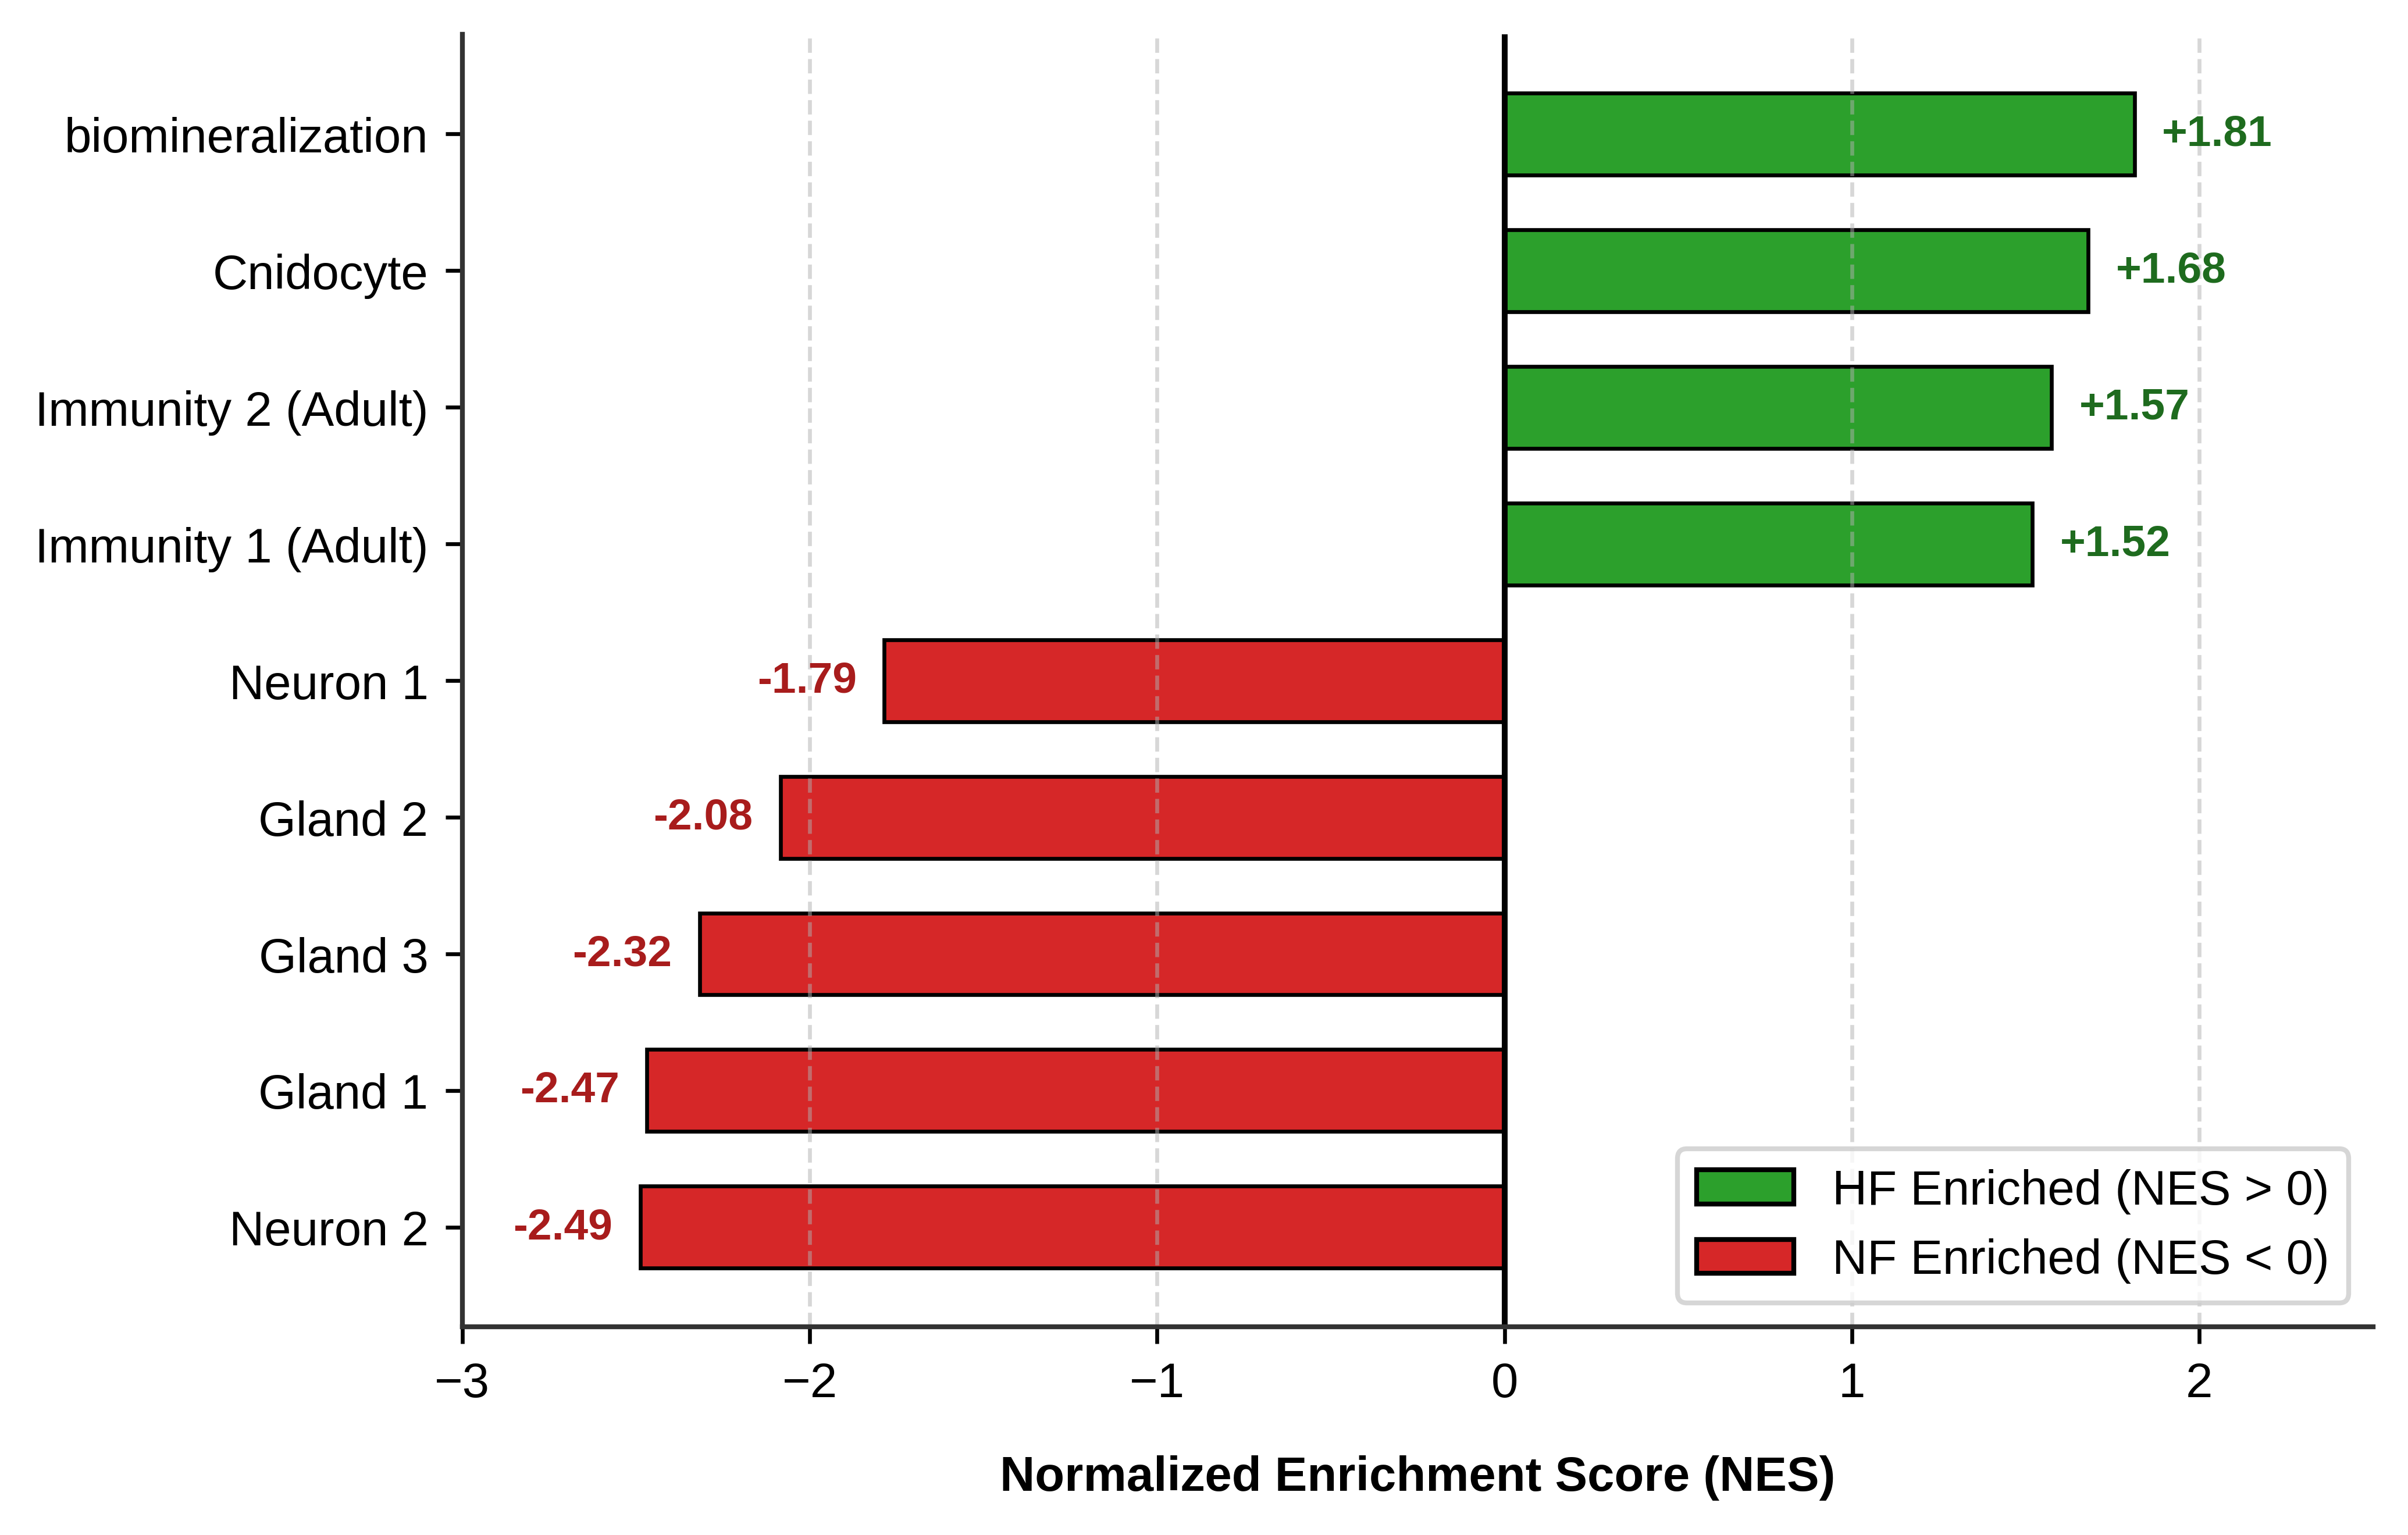

✅ GSEA plot saved successfully as:
 - GSEA_Cell_Atlas_HF_vs_NF_Plot.png
 - GSEA_Cell_Atlas_HF_vs_NF_Plot.svg
 - GSEA_Cell_Atlas_HF_vs_NF_Plot.tiff


In [21]:
import matplotlib.pyplot as plt

# Initialize figure
fig, ax = plt.subplots(figsize=(7, 4.5))

# Define colors (Green for HF/NES > 0, Red for NF/NES < 0)
colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_gsea_sorted['NES']]

# Create horizontal bar plot
bars = ax.barh(
    y=df_gsea_sorted['Clean_Pathway'],
    width=df_gsea_sorted['NES'],
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.6
)

# Add baseline zero line
ax.axvline(0, color='black', linewidth=1.2, linestyle='-')

# Add numeric value labels
for bar in bars:
    w = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2.0
    if w > 0:
        ax.text(w + 0.08, y_pos, f'+{w:.2f}', va='center', ha='left', fontsize=9, fontweight='bold', color='#1e6b1e')
    else:
        ax.text(w - 0.08, y_pos, f'{w:.2f}', va='center', ha='right', fontsize=9, fontweight='bold', color='#a81c1c')

# Formatting axes
ax.set_xlabel('Normalized Enrichment Score (NES)', fontsize=10, fontweight='bold', labelpad=10)
#ax.set_title('Cell-Atlas Gene Set Enrichment Analysis (GSEA: HF vs. NF Planulae)', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Adjust x-limits
ax.set_xlim(-3.0, 2.5)

# Hide top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', edgecolor='black', label='HF Enriched (NES > 0)'),
    Patch(facecolor='#d62728', edgecolor='black', label='NF Enriched (NES < 0)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

plt.tight_layout()

# Save in high resolution (600 DPI)
output_base = 'GSEA_Cell_Atlas_HF_vs_NF_Plot'
fig.savefig(f'{output_base}.png', dpi=600, bbox_inches='tight', format='png')
fig.savefig(f'{output_base}.svg', dpi=600, bbox_inches='tight', format='svg')
fig.savefig(f'{output_base}.tiff', dpi=600, bbox_inches='tight', format='tiff')

plt.show()

print(f"✅ GSEA plot saved successfully as:\n - {output_base}.png\n - {output_base}.svg\n - {output_base}.tiff")